In [1]:
import matplotlib.pyplot as plt
from data_processing import (
    load_heart_disease_data,
    preprocess_data,
    prepare_regression_data,
    prepare_classification_data, 
    split_and_scale
)
from regression import (
    train_elasticnet_grid,
    create_r2_heatmap,
    get_best_elasticnet_model
)
from evaluation import (
    generate_auroc_curve,
    generate_auprc_curve,
    plot_comparison_curves
)
from classification import (
    get_best_logistic_regression,
    get_best_knn  
)
import warnings
warnings.filterwarnings('ignore',category=FutureWarning)

In [2]:
df= load_heart_disease_data("../data/heart_disease_uci.csv")
df= preprocess_data(df)


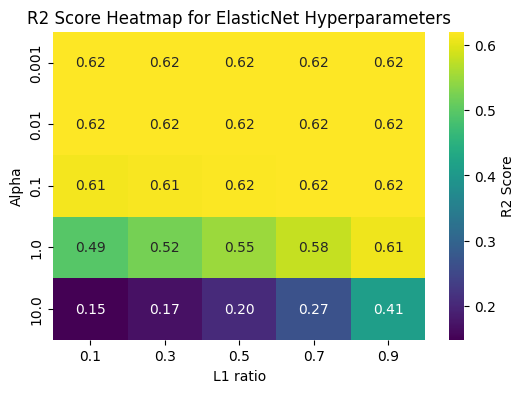

In [3]:
X_reg, y_reg = prepare_regression_data(df)
X_train, X_test, y_train, y_test, scaler = split_and_scale(X_reg, y_reg)
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]
alphas = [0.001, 0.01, 0.1, 1, 10]

results_df = train_elasticnet_grid(X_train, y_train, l1_ratios, alphas)

create_r2_heatmap(
    results_df, l1_ratios, alphas,
    output_path="elasticnet_heatmap.png"
)
plt.show()



In [5]:
X_clf, y_clf = prepare_classification_data(df)
X_train, X_test, y_train, y_test, scaler = split_and_scale(X_clf, y_clf)

In [6]:
log_results = get_best_logistic_regression(X_train, y_train,X_test, y_test)
knn_results = get_best_knn(X_train,y_train,X_test, y_test)

log_model= log_results["model"]
log_model = knn_results["model"]

In [7]:
y_prob_log= log_model.predict_proba(X_test)[:,1]
y_prob_knn= log_model.predict_proba(X_test)[:,1]

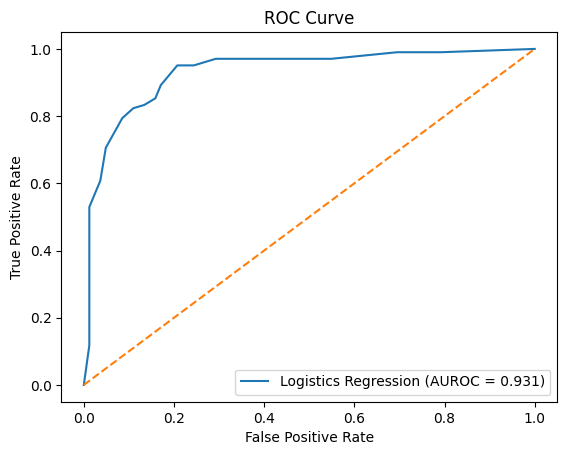

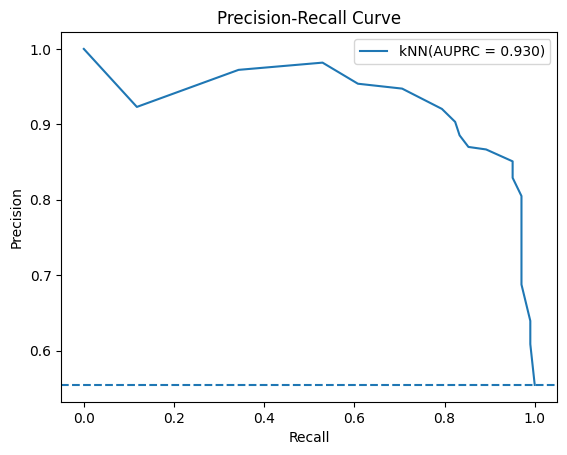

In [8]:
generate_auroc_curve(
    y_test, 
    y_prob_log,
    "Logistics Regression",
    "roc_logistic.png"
)
generate_auprc_curve(
    y_test,
    y_prob_knn,
    "kNN",
    "pr_knn.png"
)
plt.show()

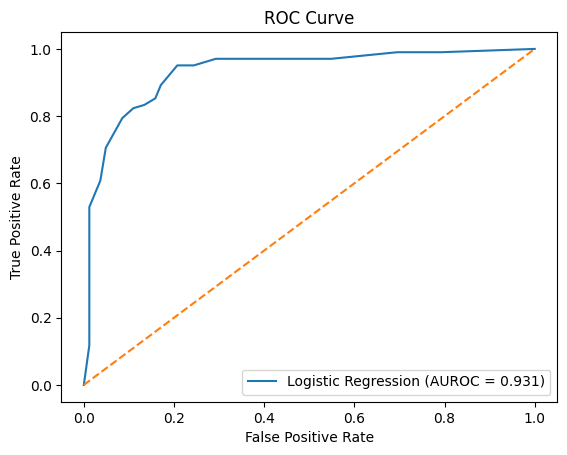

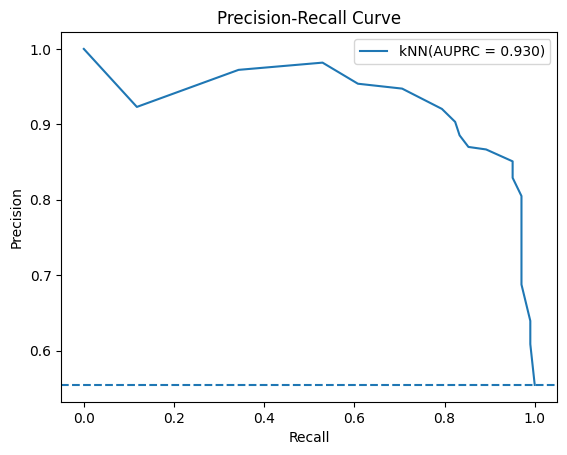

In [9]:
generate_auroc_curve(
    y_test, y_prob_log,
    "Logistic Regression",
    "roc_logistic.png" 
)
generate_auprc_curve(
    y_test, y_prob_knn,
    "kNN",
    "pr_kNN.png"
)
plt.show()

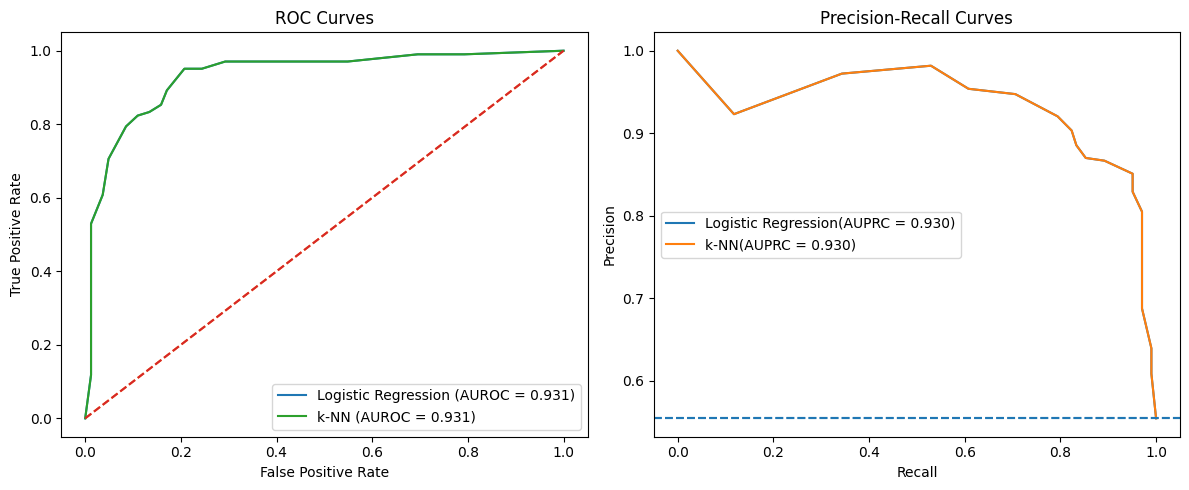

In [10]:
plot_comparison_curves(y_test, y_prob_log,y_prob_knn, output_path="comparison.png" )
plt.show()